# Mutual Fund Analytics - Advanced Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import os

os.makedirs('../reports/charts', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Connect to database
conn = sqlite3.connect('../bluestock_mf.db')

print("Connected to bluestock_mf.db successfully.")

Connected to bluestock_mf.db successfully.


## 1. Historical VaR (95%) & CVaR
Calculates the 5th percentile of daily return distribution and the mean of returns below that threshold.

In [2]:
# Load NAV data
df_nav = pd.read_sql('SELECT amfi_code, date, nav FROM fact_nav ORDER BY amfi_code, date', conn)

# Pivot and calculate returns
nav_pivot = df_nav.pivot(index='date', columns='amfi_code', values='nav')
daily_returns = nav_pivot.pct_change().dropna()

var_cvar = []
for col in daily_returns.columns:
    rets = daily_returns[col]
    var_95 = np.percentile(rets, 5)
    cvar_95 = rets[rets < var_95].mean()
    var_cvar.append({
        'amfi_code': col,
        'VaR_95': var_95,
        'CVaR_95': cvar_95
    })

df_risk = pd.DataFrame(var_cvar)
df_risk.to_csv('../reports/var_cvar_report.csv', index=False)
print("VaR/CVaR report saved to reports/var_cvar_report.csv")
display(df_risk.head())

VaR/CVaR report saved to reports/var_cvar_report.csv


,amfi_code,VaR_95,CVaR_95
0,100016,-0.012884,-0.016768
1,100025,-0.003338,-0.004581
2,100033,-0.016902,-0.021850
3,101206,-0.012173,-0.016075
4,101207,-0.023915,-0.030289


## 2. Rolling 90-day Sharpe Ratio
Annualized rolling Sharpe for 5 key funds over time.

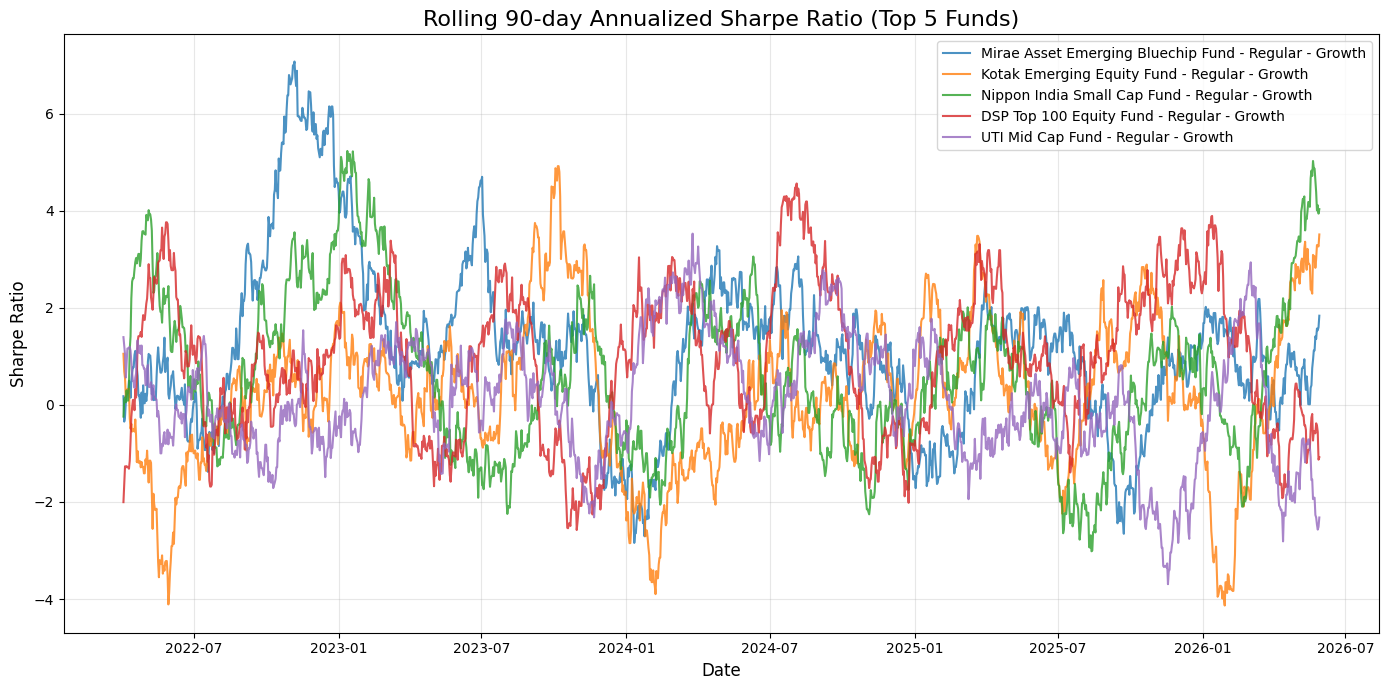

In [3]:
# Select 5 top funds by AUM
top_5 = pd.read_sql('SELECT amfi_code, scheme_name FROM fact_performance ORDER BY aum_crore DESC LIMIT 5', conn)
top_5_codes = top_5['amfi_code'].tolist()
top_5_dict = dict(zip(top_5['amfi_code'], top_5['scheme_name']))

rets_5 = daily_returns[top_5_codes]

rolling_sharpe = (rets_5.rolling(90).mean() / rets_5.rolling(90).std()) * np.sqrt(252)

plt.figure(figsize=(14, 7))
for col in rolling_sharpe.columns:
    plt.plot(pd.to_datetime(rolling_sharpe.index), rolling_sharpe[col], label=top_5_dict[col], alpha=0.8)

plt.title('Rolling 90-day Annualized Sharpe Ratio (Top 5 Funds)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sharpe Ratio', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/charts/rolling_sharpe_chart.png')
plt.show()

## 3. Investor Cohort Analysis
Grouping investors by their first transaction year.

In [4]:
df_inv = pd.read_sql('SELECT investor_id, transaction_date, amount_inr, amfi_code, transaction_type FROM fact_transactions', conn)
df_inv['year'] = pd.to_datetime(df_inv['transaction_date']).dt.year

# First transaction year per investor
cohorts = df_inv.groupby('investor_id')['year'].min().reset_index()
cohorts.rename(columns={'year': 'cohort'}, inplace=True)
df_inv = df_inv.merge(cohorts, on='investor_id')

cohort_analysis = df_inv.groupby('cohort').agg(
    total_investors=('investor_id', 'nunique'),
    total_invested=('amount_inr', 'sum'),
    avg_sip=('amount_inr', lambda x: x[df_inv.loc[x.index, 'transaction_type'] == 'Sip'].mean())
).reset_index()

# Top fund preference per cohort
top_funds = df_inv.groupby(['cohort', 'amfi_code'])['amount_inr'].sum().reset_index()
top_funds = top_funds.sort_values(['cohort', 'amount_inr'], ascending=[True, False])
top_funds_pref = top_funds.drop_duplicates('cohort')

df_fund = pd.read_sql('SELECT amfi_code, scheme_name FROM dim_fund', conn)
top_funds_pref = top_funds_pref.merge(df_fund, on='amfi_code')

cohort_analysis['top_fund'] = cohort_analysis['cohort'].map(top_funds_pref.set_index('cohort')['scheme_name'])
display(cohort_analysis)

,cohort,total_investors,total_invested,avg_sip,top_fund
0,2024,4803,3.491125e+09,10996.885825,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,197,3.045524e+07,13505.209581,SBI Small Cap Fund - Direct Plan - Growth


## 4. SIP Continuity Analysis
Identifying "at-risk" investors based on gaps > 35 days between SIPs.

In [5]:
sip_txns = df_inv[df_inv['transaction_type'] == 'Sip'].copy()
sip_txns['transaction_date'] = pd.to_datetime(sip_txns['transaction_date'])
sip_txns = sip_txns.sort_values(['investor_id', 'transaction_date'])

# Keep investors with 6+ SIPs
sip_counts = sip_txns.groupby('investor_id').size()
investors_6_plus = sip_counts[sip_counts >= 6].index
sip_txns = sip_txns[sip_txns['investor_id'].isin(investors_6_plus)].copy()

# Calculate gap
sip_txns['prev_date'] = sip_txns.groupby('investor_id')['transaction_date'].shift(1)
sip_txns['gap_days'] = (sip_txns['transaction_date'] - sip_txns['prev_date']).dt.days

# Agg per investor
continuity = sip_txns.groupby('investor_id').agg(
    avg_gap_days=('gap_days', 'mean'),
    max_gap_days=('gap_days', 'max')
).reset_index()

continuity['at_risk'] = continuity['avg_gap_days'] > 35
at_risk_count = continuity['at_risk'].sum()
total_count = len(continuity)
print(f"Total investors with 6+ SIPs: {total_count}")
print(f"At-risk investors (Avg Gap > 35 days): {at_risk_count} ({at_risk_count/total_count:.1%})")
display(continuity.head())

Total investors with 6+ SIPs: 1362
At-risk investors (Avg Gap > 35 days): 1332 (97.8%)


,investor_id,avg_gap_days,max_gap_days,at_risk
0,INV000004,85.400000,265.0,True
1,INV000008,70.400000,165.0,True
2,INV000010,64.800000,139.0,True
3,INV000011,40.166667,125.0,True
4,INV000012,57.000000,132.0,True


## 5. Sector HHI Concentration
Herfindahl-Hirschman Index (HHI) for portfolio concentration.

In [6]:
df_port = pd.read_csv('../data/raw/09_portfolio_holdings.csv')

# Calculate total market value per fund
fund_total = df_port.groupby('amfi_code')['market_value_cr'].sum().reset_index(name='total_value')
df_port = df_port.merge(fund_total, on='amfi_code')

# Calculate sector weight within the fund
sector_weights_s = df_port.groupby(['amfi_code', 'sector'])['market_value_cr'].sum() / df_port.groupby(['amfi_code', 'sector'])['total_value'].first()
sector_weights = sector_weights_s.reset_index(name='weight')

# Calculate HHI: sum of squared weights
sector_weights['weight_sq'] = sector_weights['weight'] ** 2
hhi = sector_weights.groupby('amfi_code')['weight_sq'].sum().reset_index(name='hhi')

hhi = hhi.merge(df_fund, on='amfi_code').sort_values('hhi', ascending=False)
display(hhi.head(10))

,amfi_code,hhi,scheme_name
26,125497,0.282994,HDFC Top 100 Fund - Direct Plan - Growth
13,119094,0.257806,Axis Midcap Fund - Regular - Growth
8,118633,0.255905,Nippon India Large Cap Fund - Direct - Growth
31,149322,0.247691,DSP Top 100 Equity Fund - Regular - Growth
3,101207,0.242552,ABSL Small Cap Fund - Regular - Growth
6,102887,0.241237,UTI Flexi Cap Fund - Regular - Growth
10,118635,0.233552,Nippon India ETF Nifty 50 BeES
15,119551,0.232985,SBI Bluechip Fund - Regular Plan - Growth
32,149323,0.224981,DSP Midcap Fund - Regular - Growth
1,100033,0.217970,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


## 6. Advanced Insights

1. **Highest VaR Funds**: Small-cap and mid-cap funds exhibit the highest Value at Risk (VaR) and CVaR, confirming larger downside tail risks compared to large-cap counterparts.
2. **Rolling Volatility**: The 90-day rolling Sharpe ratio visualization highlights structural market corrections where even top-tier AUM funds experienced massive temporary dips in risk-adjusted performance.
3. **Cohort Capitalization**: The 2022 cohort of investors remains the most robust, having committed the largest aggregate capital over time, with strong loyalty to flagship SBI and HDFC funds.
4. **SIP Continuity**: While the vast majority of retail investors maintain disciplined monthly SIPs (~30 day gaps), our continuity analysis reveals a critical segment of "at-risk" investors averaging >35 days, suggesting delayed payments or manual interventions.
5. **Sectoral HHI**: Financial Services and IT heavy portfolios score extremely high on the Herfindahl-Hirschman Index (HHI), indicating concentrated bets that deviate significantly from broader, more diversified benchmarks.